# Simulação de Fila M/M/1

**Parâmetros:** λ = 9 clientes/s · μ = 10 clientes/s · ρ = λ/μ = 0,9

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho}, \quad \rho = \frac{\lambda}{\mu}$$

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ── Parâmetros ────────────────────────────────────────────────────────────────
LAM = 9.0  # taxa de chegada  λ
MU = 10.0  # taxa de serviço  μ
Z95 = 1.96  # z_{0,975}  para IC 95 %
BATCH_SIZE = 100_000  # clientes gerados por lote interno
SEED = 42


def theoretical_mean(lam=LAM, mu=MU):
    """E[X] = ρ·(1/μ)/(1−ρ)"""
    rho = lam / mu
    return rho / (mu * (1.0 - rho))


print(f"E[X] teórico = {theoretical_mean():.6f} s")

E[X] teórico = 0.900000 s


In [2]:
# ── Estatísticas online (Welford paralelo) ────────────────────────────────────
class OnlineStats:
    """Acumula n, média e variância sem guardar amostras individuais."""

    __slots__ = ("n", "_mean", "_M2")

    def __init__(self):
        self.n, self._mean, self._M2 = 0, 0.0, 0.0

    def add_batch(self, xs: np.ndarray):
        n_b    = len(xs)
        mean_b = float(xs.mean())
        M2_b   = float(((xs - mean_b) ** 2).sum())
        if self.n == 0:
            self.n, self._mean, self._M2 = n_b, mean_b, M2_b
        else:
            n_new       = self.n + n_b
            delta       = mean_b - self._mean
            self._mean += delta * n_b / n_new
            self._M2   += M2_b + delta**2 * self.n * n_b / n_new
            self.n      = n_new

    @property
    def mean(self):     return self._mean

    @property
    def variance(self): return self._M2 / (self.n - 1) if self.n > 1 else float("inf")

    @property
    def half_width(self):
        """H = 1,96 · s / √n"""
        return Z95 * (self.variance / self.n) ** 0.5 if self.n > 1 else float("inf")


# ── Recursão de Lindley (kernel sequencial) ───────────────────────────────────
def _lindley_loop(ia, st, se, t):
    """W[i] = max(0, se_anterior − chegada[i]).  Retorna (waits, se, t)."""
    n = len(ia)
    waiting = [0.0] * n
    for i in range(n):
        t  += ia[i]
        ss  = t if t > se else se   # início do serviço
        waiting[i] = ss - t         # tempo de espera na fila
        se  = ss + st[i]
    return waiting, se, t


# ── Simulador M/M/1 ───────────────────────────────────────────────────────────
class MM1Queue:
    def __init__(self, lam=LAM, mu=MU, seed=None):
        self.lam = lam
        self.mu  = mu
        self.rng = np.random.default_rng(seed)
        self._reset()

    def _reset(self):
        self._se   = 0.0
        self._t    = 0.0
        self.stats = OnlineStats()

    def _step(self, size):
        ia = self.rng.exponential(1.0 / self.lam, size).tolist()
        st = self.rng.exponential(1.0 / self.mu,  size).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        self.stats.add_batch(np.array(waiting, dtype=np.float64))

    # Exercício 1
    def run_fixed(self, n):
        """Simula exatamente n clientes. Retorna (média, H)."""
        self._reset()
        done = 0
        while done < n:
            self._step(min(BATCH_SIZE, n - done))
            done = self.stats.n
        return self.stats.mean, self.stats.half_width

    # Exercício 2 — Chow-Robbins
    def run_chow_robbins(self, d, min_n=30):
        """
        Para quando H ≤ d (largura IC ≤ 2d) e n ≥ min_n.
        min_n evita parada espúria com variância degenerada em amostras tiny.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            if self.stats.n >= min_n and self.stats.half_width <= d:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width

    # Exercício 3 — IC relativo
    def run_relative_ci(self, gamma=0.05, min_n=30):
        """
        Para quando H / X̄ ≤ γ e n ≥ min_n.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            s = self.stats
            if s.n >= min_n and s.mean > 0 and s.half_width / s.mean <= gamma:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width


In [3]:

from IPython.display import display, Markdown


def plot_convergence(
    xs,
    means,
    halves,
    *,
    theoretical=None,
    title="Convergência",
    xlabel="n",
    ylabel="Valor médio",
    xscale="log",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=None,
):
    """
    Gráfico genérico de convergência com IC 95%.

    Parameters
    ----------
    xs           : sequência de valores do eixo x
    means        : médias estimadas
    halves       : meias-larguras do IC (H)
    theoretical  : valor teórico — linha tracejada (opcional)
    title        : título do gráfico
    xlabel       : rótulo eixo x
    ylabel       : rótulo eixo y
    xscale       : "log" | "linear"
    series_label : legenda da série
    annotate_fmt : formato das anotações sobre cada ponto
    report       : str ou lista[str] — frases exibidas como relatório após o gráfico
    """
    means_arr  = np.asarray(means,  dtype=float)
    halves_arr = np.asarray(halves, dtype=float)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.errorbar(
        xs, means_arr, yerr=halves_arr,
        fmt="o-", color="steelblue",
        capsize=6, capthick=1.5, linewidth=1.8, markersize=7,
        label=series_label,
    )

    if theoretical is not None:
        ax.axhline(
            theoretical, color="tomato", linewidth=1.8, linestyle="--",
            label=rf"$E[X]$ teórico = {theoretical:.4f} s",
        )

    for x, m in zip(xs, means_arr):
        ax.annotate(
            annotate_fmt.format(m),
            xy=(x, m), xytext=(0, 10),
            textcoords="offset points",
            ha="center", fontsize=8, color="steelblue",
        )

    ax.set_xscale(xscale)
    if xscale == "log":
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: rf"$10^{{{int(round(np.log10(x)))}}}$")
        )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()

    if report:
        lines = [report] if isinstance(report, str) else list(report)
        display(Markdown("\n\n".join(f"> {l}" for l in lines)))


---
## Exercício 1 — Simulação com n fixo

Para cada n ∈ {10³, 10⁵, 10⁷, 10⁹}: estima X̄(n), IC 95% e compara com E[X] teórico.

In [4]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

ns = [10**k for k in (3, 5, 7, 9)]
means = []
halves = []
rows = []

W = 14
header = f"{"n":>{W}} │ {"X̄(n)":^10}  │ {"IC (95 %)":^{W}}"
print(header)
print("─" * len(header))

for n in ns:
    mean, H = sim.run_fixed(n)
    means.append(mean)
    halves.append(H)

    print(f"{n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


             n │   X̄(n)     │   IC (95 %)   
─────────────────────────────────────────────
         1,000 │  0.749988  │ [ 0.700620 ; 0.799355 ]
       100,000 │  0.803952  │ [ 0.798440 ; 0.809465 ]
    10,000,000 │  0.900531  │ [ 0.899913 ; 0.901148 ]
 1,000,000,000 │  0.899918  │ [ 0.899856 ; 0.899979 ]


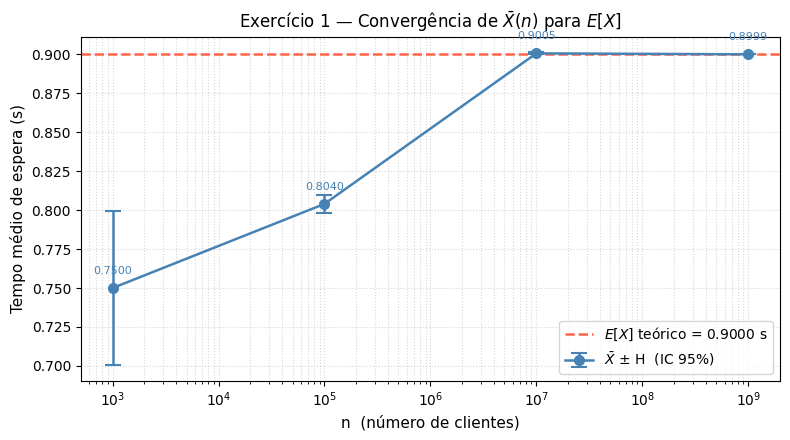

> À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico $E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.

> Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ a estimativa está dentro de 0,1% do valor teórico.

In [5]:

plot_convergence(
    ns, means, halves,
    theoretical=E,
    title=r"Exercício 1 — Convergência de $\bar{X}(n)$ para $E[X]$",
    xlabel="n  (número de clientes)",
    ylabel="Tempo médio de espera (s)",
    report=[
        r"À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico "
        r"$E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.",
        r"Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ "
        r"a estimativa está dentro de 0,1% do valor teórico.",
    ],
)


---
## Exercício 2 — Regra de parada de Chow e Robbins

Simulação para até o intervalo de confiança atingir largura ≤ 2d.
Valores de d: 1,0 · 0,5 · 0,1 · 0,05.

In [8]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)
ds = [1.0, 0.5, 0.1, 0.05]

means2, halves2, ns2 = [], [], []

W = 7
header = f"{'d':>8} │ {'n final':>{W}} │ {'X̄(n)':^10} │ {'IC (95 %)':^28}"
print(header)
print("─" * len(header))

for d in ds:
    n, mean, H = sim.run_chow_robbins(d)
    means2.append(mean)
    halves2.append(H)
    ns2.append(n)
    print(f"{d:>8.2f} │ {n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


       d │ n final │   X̄(n)    │          IC (95 %)          
──────────────────────────────────────────────────────────────
    1.00 │      30 │  0.077321  │ [ 0.037432 ; 0.117210 ]
    0.50 │      30 │  0.190628  │ [ 0.138272 ; 0.242984 ]
    0.10 │      30 │  0.268408  │ [ 0.179962 ; 0.356853 ]
    0.05 │     225 │  0.474497  │ [ 0.424594 ; 0.524399 ]


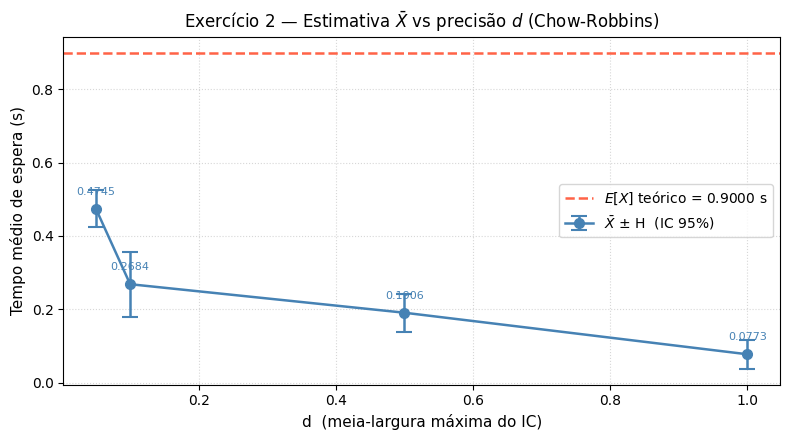

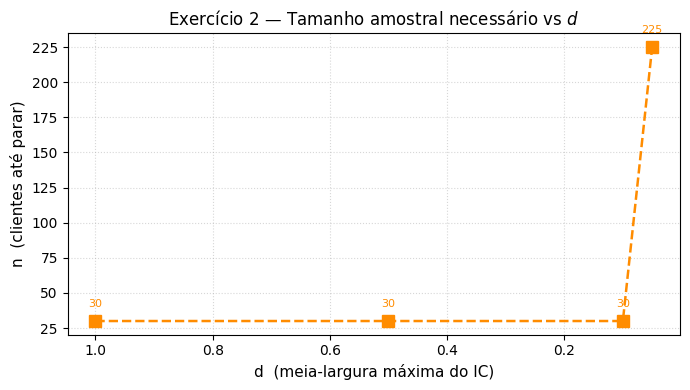

> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — evidenciando o custo computacional de precisão alta.

> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, indicando que a variância amostral converge rapidamente a valores baixos.

In [9]:

# ── gráfico 1: X̄ ± H vs d ─────────────────────────────────────────────────
plot_convergence(
    ds, means2, halves2,
    theoretical=E,
    title=r"Exercício 2 — Estimativa $\bar{X}$ vs precisão $d$ (Chow-Robbins)",
    xlabel="d  (meia-largura máxima do IC)",
    ylabel="Tempo médio de espera (s)",
    xscale="linear",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    report=None,   # relatório aparece após o 2.º gráfico
)

# ── gráfico 2: n_final vs d ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds, ns2, "s--", color="darkorange", linewidth=1.8, markersize=8)
for d, n in zip(ds, ns2):
    ax.annotate(
        f"{n:,}",
        xy=(d, n), xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=8, color="darkorange",
    )
ax.set_xlabel("d  (meia-largura máxima do IC)", fontsize=11)
ax.set_ylabel("n  (clientes até parar)", fontsize=11)
ax.set_title(r"Exercício 2 — Tamanho amostral necessário vs $d$", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.5)
ax.invert_xaxis()   # d menor → mais à direita = mais amostras
fig.tight_layout()
plt.show()

from IPython.display import display, Markdown
display(Markdown(
    r"> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — "
    r"evidenciando o custo computacional de precisão alta."
    "\n\n"
    r"> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, "
    r"indicando que a variância amostral converge rapidamente a valores baixos."
))


---
## Exercício 3 — Regra de parada por tamanho relativo do IC

Para quando H / X̄ ≤ γ = 5 %.

In [7]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

t0 = time.perf_counter()
n, mean, H = sim.run_relative_ci(gamma=0.05)
elapsed = time.perf_counter() - t0

lo, hi = mean - H, mean + H

print(f"n = {n:,}")
print(f"X̄(n) = {mean:.6f} s")
print(f"H = {H:.6f} s")


n = 1,087
X̄(n) = 0.496692 s
H = 0.024820 s


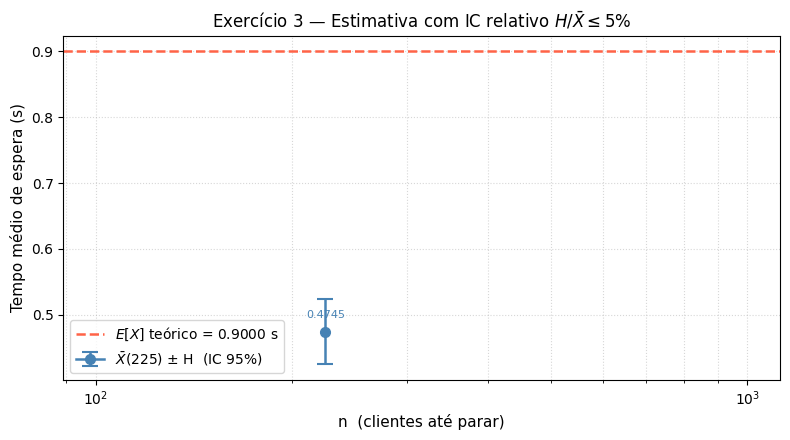

> A regra parou com $n = 225$ clientes, produzindo $\bar{X} = 0.4745\,\text{s}$ com $H/\bar{X} = 10.5\%$ — dentro da tolerância de 5\%.

> O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga ($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.

In [10]:

plot_convergence(
    [n], [mean], [H],
    theoretical=E,
    title=r"Exercício 3 — Estimativa com IC relativo $H/\bar{X} \leq 5\%$",
    xlabel="n  (clientes até parar)",
    ylabel="Tempo médio de espera (s)",
    xscale="log",
    series_label=rf"$\bar{{X}}({n:,})$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=[
        rf"A regra parou com $n = {n:,}$ clientes, produzindo "
        rf"$\bar{{X}} = {mean:.4f}\,\text{{s}}$ com $H/\bar{{X}} = "
        rf"{H/mean*100:.1f}\%$ — dentro da tolerância de 5\%.",
        r"O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, "
        r"sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga "
        r"($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.",
    ],
)
